<a href="https://colab.research.google.com/github/monteiro-sara/algorithmic_trading/blob/main/NLP_Sentiment_Trading_Strategy_Yahoo_FinBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Sentiment Analysis for a Trading Strategy
## Yahoo Finance News + FinBERT + Technical Confirmation + Forward Logging

This notebook turns recent financial-news headlines into an **auditable research signal**.

Pipeline:

**Yahoo Finance news → text normalization → FinBERT → event classification → recency-weighted sentiment → technical confirmation → research signal → forward log**

The notebook does **not** pretend that sentiment is a probability of profit. It separates:

- model sentiment,
- news recency,
- event type,
- technical price context,
- signal generation,
- forward validation.

Yahoo's recent-news feed is useful for current monitoring, but it is not a deep historical news database. For that reason, this notebook logs its own timestamped observations so future returns can be evaluated honestly as data accumulate.

In [1]:
# Colab setup
!pip -q install "yfinance==1.5.2" "transformers>=4.45" torch plotly scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 6.0 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import os
import re
import math
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import yfinance as yf

import torch
from transformers import pipeline

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

print("yfinance:", yf.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

yfinance: 1.5.2
torch: 2.11.0+cpu
CUDA available: False


## 1. Configuration

Use one symbol for detailed analysis or several symbols for the scanner.

Examples:

- `AAPL`
- `MSFT`
- `NVDA`
- `META`
- `SPY`
- `QQQ`
- `BTC-USD`

The FinBERT model is finance-specific and classifies text as **positive**, **negative**, or **neutral**.

In [3]:
# ---------------- Core analysis ----------------
TICKER = "NVDA"
NEWS_COUNT = 30

# Yahoo price context
PRICE_PERIOD = "5d"
PRICE_INTERVAL = "5m"
PREPOST = False

# FinBERT
FINBERT_MODEL = "ProsusAI/finbert"
BATCH_SIZE = 16

# Sentiment weighting
RECENCY_HALF_LIFE_HOURS = 12.0
MIN_DIRECTIONAL_CONFIDENCE = 0.10

# Research-signal thresholds
SENTIMENT_BULLISH_THRESHOLD = 0.15
SENTIMENT_BEARISH_THRESHOLD = -0.15
TECH_BULLISH_THRESHOLD = 1.0
TECH_BEARISH_THRESHOLD = -1.0

# Forward logging
LOG_DIR = Path("/content/sentiment_trading_logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

NEWS_LOG_FILE = LOG_DIR / "news_sentiment_log.csv"
SIGNAL_LOG_FILE = LOG_DIR / "signal_log.csv"

# Scanner
SCANNER_TICKERS = [
    "AAPL", "MSFT", "NVDA", "META",
    "AMZN", "GOOGL", "SPY", "QQQ"
]

# ---------- Visual / reporting settings ----------
VISUAL_TOP_N = 20
FORWARD_HORIZONS_MINUTES = (5, 30, 60)

SENTIMENT_RED = "#EF4444"
SENTIMENT_YELLOW = "#FACC15"
SENTIMENT_GREEN = "#22C55E"
SENTIMENT_GREY = "#9CA3AF"

def sentiment_color(score):
    if pd.isna(score):
        return SENTIMENT_GREY
    if score >= SENTIMENT_BULLISH_THRESHOLD:
        return SENTIMENT_GREEN
    if score <= SENTIMENT_BEARISH_THRESHOLD:
        return SENTIMENT_RED
    return SENTIMENT_YELLOW

def sentiment_label(score):
    if pd.isna(score):
        return "NO DATA"
    if score >= 0.35:
        return "STRONGLY POSITIVE"
    if score >= SENTIMENT_BULLISH_THRESHOLD:
        return "POSITIVE"
    if score <= -0.35:
        return "STRONGLY NEGATIVE"
    if score <= SENTIMENT_BEARISH_THRESHOLD:
        return "NEGATIVE"
    return "NEUTRAL / MIXED"


## 2. Load FinBERT

The first run downloads the model weights. A GPU is helpful but not required.

The score used later is:

`sentiment_score = P(positive) - P(negative)`

So it ranges approximately from **-1 to +1**.

In [4]:
DEVICE = 0 if torch.cuda.is_available() else -1

finbert = pipeline(
    task="text-classification",
    model=FINBERT_MODEL,
    tokenizer=FINBERT_MODEL,
    device=DEVICE,
)

print("FinBERT loaded on:", "GPU" if DEVICE == 0 else "CPU")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded on: CPU


## 3. Download and normalize recent Yahoo Finance news

`yfinance` news output has changed structure across versions.  
The normalizer below accepts both newer nested records and older flatter records.

In [5]:
def _safe_get(obj, *keys, default=None):
    cur = obj
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def _parse_datetime(value):
    if value is None or value == "":
        return pd.NaT

    # Unix seconds / milliseconds
    if isinstance(value, (int, float, np.integer, np.floating)):
        value = int(value)
        unit = "ms" if value > 10_000_000_000 else "s"
        return pd.to_datetime(value, unit=unit, utc=True, errors="coerce")

    return pd.to_datetime(value, utc=True, errors="coerce")


def normalize_yahoo_news_item(item, ticker):
    content = item.get("content", item) if isinstance(item, dict) else {}

    title = (
        content.get("title")
        or item.get("title")
        or ""
    )

    summary = (
        content.get("summary")
        or content.get("description")
        or item.get("summary")
        or ""
    )

    provider = (
        _safe_get(content, "provider", "displayName")
        or content.get("publisher")
        or item.get("publisher")
        or ""
    )

    url = (
        _safe_get(content, "canonicalUrl", "url")
        or _safe_get(content, "clickThroughUrl", "url")
        or content.get("link")
        or item.get("link")
        or ""
    )

    published = (
        content.get("pubDate")
        or content.get("displayTime")
        or item.get("providerPublishTime")
        or item.get("pubDate")
    )

    related = (
        content.get("finance", {}).get("stockTickers", [])
        if isinstance(content.get("finance"), dict)
        else []
    )
    if not related:
        related = item.get("relatedTickers", [])

    if isinstance(related, list):
        related = ",".join(
            str(x.get("symbol", x)) if isinstance(x, dict) else str(x)
            for x in related
        )

    text = title.strip()
    if summary and summary.strip() and summary.strip() != title.strip():
        text = f"{title.strip()}. {summary.strip()}"

    article_id = (
        item.get("id")
        or content.get("id")
        or hashlib.sha1(
            f"{ticker}|{published}|{title}|{url}".encode("utf-8")
        ).hexdigest()
    )

    return {
        "article_id": str(article_id),
        "ticker": ticker,
        "published_at": _parse_datetime(published),
        "title": title.strip(),
        "summary": summary.strip(),
        "text": text.strip(),
        "provider": str(provider),
        "url": str(url),
        "related_tickers": str(related),
    }


def fetch_yahoo_news(ticker, count=NEWS_COUNT):
    raw = []

    # First try ticker-specific news.
    try:
        raw = yf.Ticker(ticker).get_news(
            count=count,
            tab="news",
        )
    except Exception as exc:
        print(f"{ticker}: Ticker.get_news failed:", exc)

    # Search is a useful fallback and sometimes returns more relevant news.
    if not raw:
        try:
            raw = yf.Search(
                ticker,
                news_count=count,
                max_results=1,
            ).news
        except Exception as exc:
            print(f"{ticker}: yf.Search news failed:", exc)

    rows = [
        normalize_yahoo_news_item(item, ticker)
        for item in (raw or [])
    ]

    news = pd.DataFrame(rows)

    if news.empty:
        return pd.DataFrame(
            columns=[
                "article_id", "ticker", "published_at",
                "title", "summary", "text", "provider",
                "url", "related_tickers"
            ]
        )

    news = (
        news.drop_duplicates("article_id")
        .drop_duplicates(["published_at", "title"])
        .sort_values("published_at", ascending=False)
        .reset_index(drop=True)
    )

    return news


news_df = fetch_yahoo_news(TICKER)

print(f"{TICKER}: {len(news_df)} recent Yahoo news items")
display(news_df[["published_at", "provider", "title"]].head(10))

NVDA: 30 recent Yahoo news items


,published_at,provider,title
0,2026-08-21 22:17:00+00:00,TheStreet,Morgan Stanley resets Nvidia stock forecast ah...
1,2026-08-21 22:14:57+00:00,Motley Fool,Why Did Critical Metals Stock Just Gain 22.6%?
2,2026-08-21 22:10:03+00:00,BeInCrypto,Nvidia Stock Suffers Longest Losing Streak Sin...
3,2026-08-21 22:00:54+00:00,Motley Fool,Why Amylyx Pharmaceuticals Blasted Nearly 79% ...
4,2026-08-21 21:57:52+00:00,Motley Fool,Why Ross Stores Stock Is Up Today
5,2026-08-21 21:53:01+00:00,Motley Fool,Warren Buffett Successor Greg Abel Cut Berkshi...
6,2026-08-21 21:50:34+00:00,Motley Fool,The Wild Swings of Earnings Season Continue
7,2026-08-21 21:48:44+00:00,Stocktwits,US Stock Indices End Week Lower On Pressure Fr...
8,2026-08-21 21:46:33+00:00,Motley Fool,Why Is Tesla Stock Up Today?
9,2026-08-21 21:35:03+00:00,24/7 Wall St.,Two Years of Friday Paydays: The 44% Fund Has ...


## 4. Event-type interpreter

Sentiment alone is incomplete.

A positive product headline and a positive earnings-surprise headline may have different market relevance.  
This lightweight classifier labels each story using transparent keyword rules.

It is not intended to replace a trained event-extraction model; it simply makes the interpretation more useful.

In [6]:
EVENT_PATTERNS = {
    "earnings": [
        r"\bearnings\b", r"\beps\b", r"quarterly results",
        r"revenue", r"profit", r"loss", r"beat estimates",
        r"missed estimates",
    ],
    "guidance": [
        r"guidance", r"forecast", r"outlook", r"raises? .* forecast",
        r"cuts? .* forecast", r"expects? .* revenue",
    ],
    "analyst_action": [
        r"upgrade", r"downgrade", r"price target", r"initiates? coverage",
        r"overweight", r"underweight", r"buy rating", r"sell rating",
    ],
    "m_and_a": [
        r"acqui", r"merger", r"takeover", r"buyout",
        r"strategic transaction", r"deal to buy",
    ],
    "regulatory_legal": [
        r"lawsuit", r"regulator", r"antitrust", r"investigation",
        r"sec\b", r"doj\b", r"ftc\b", r"fine\b",
        r"court", r"legal action",
    ],
    "product_technology": [
        r"launch", r"unveil", r"new product", r"chip", r"ai model",
        r"platform", r"software", r"technology", r"partnership",
    ],
    "capital_returns": [
        r"dividend", r"buyback", r"repurchase", r"shareholder return",
    ],
    "management": [
        r"ceo", r"cfo", r"chairman", r"resigns?", r"appoints?",
        r"executive",
    ],
    "macro_market": [
        r"inflation", r"interest rate", r"fed\b", r"ecb\b",
        r"jobs report", r"gdp\b", r"tariff", r"recession",
        r"market selloff", r"market rally",
    ],
}


def classify_event_type(text):
    text = str(text).lower()

    scores = {}
    for event, patterns in EVENT_PATTERNS.items():
        score = sum(bool(re.search(pattern, text)) for pattern in patterns)
        scores[event] = score

    best_event = max(scores, key=scores.get)

    return best_event if scores[best_event] > 0 else "other"


news_df["event_type"] = news_df["text"].map(classify_event_type)

news_df[["published_at", "event_type", "title"]].head(15)

,published_at,event_type,title
0,2026-08-21 22:17:00+00:00,earnings,Morgan Stanley resets Nvidia stock forecast ah...
1,2026-08-21 22:14:57+00:00,management,Why Did Critical Metals Stock Just Gain 22.6%?
2,2026-08-21 22:10:03+00:00,earnings,Nvidia Stock Suffers Longest Losing Streak Sin...
3,2026-08-21 22:00:54+00:00,other,Why Amylyx Pharmaceuticals Blasted Nearly 79% ...
4,2026-08-21 21:57:52+00:00,other,Why Ross Stores Stock Is Up Today
5,2026-08-21 21:53:01+00:00,management,Warren Buffett Successor Greg Abel Cut Berkshi...
6,2026-08-21 21:50:34+00:00,earnings,The Wild Swings of Earnings Season Continue
7,2026-08-21 21:48:44+00:00,other,US Stock Indices End Week Lower On Pressure Fr...
8,2026-08-21 21:46:33+00:00,regulatory_legal,Why Is Tesla Stock Up Today?
9,2026-08-21 21:35:03+00:00,other,Two Years of Friday Paydays: The 44% Fund Has ...


## 5. FinBERT sentiment scoring

For every article we keep the full probability distribution:

- `p_positive`
- `p_negative`
- `p_neutral`

The signed score is:

`p_positive - p_negative`

This preserves more information than storing only the winning class.

In [7]:
def _scores_to_dict(scores):
    result = {
        "positive": np.nan,
        "negative": np.nan,
        "neutral": np.nan,
    }

    for item in scores:
        label = str(item["label"]).lower()
        score = float(item["score"])

        # Handles labels such as "positive" as well as LABEL_0 variants
        # if a compatible model uses explicit id2label mapping.
        if "pos" in label:
            result["positive"] = score
        elif "neg" in label:
            result["negative"] = score
        elif "neu" in label:
            result["neutral"] = score

    return result


def score_news_finbert(news, batch_size=BATCH_SIZE):
    out = news.copy()

    if out.empty:
        for col in [
            "p_positive", "p_negative", "p_neutral",
            "sentiment_score", "sentiment_label",
            "directional_confidence",
        ]:
            out[col] = np.nan
        return out

    texts = (
        out["text"]
        .fillna("")
        .astype(str)
        .str.slice(0, 3000)
        .tolist()
    )

    raw_scores = finbert(
        texts,
        top_k=None,
        truncation=True,
        max_length=512,
        batch_size=batch_size,
    )

    rows = []

    for scores in raw_scores:
        d = _scores_to_dict(scores)

        pos = d["positive"]
        neg = d["negative"]
        neu = d["neutral"]

        signed = pos - neg

        label = max(
            [("positive", pos), ("negative", neg), ("neutral", neu)],
            key=lambda x: -np.inf if pd.isna(x[1]) else x[1],
        )[0]

        rows.append(
            {
                "p_positive": pos,
                "p_negative": neg,
                "p_neutral": neu,
                "sentiment_score": signed,
                "sentiment_label": label,
                "directional_confidence": abs(signed),
            }
        )

    scored = pd.concat(
        [out.reset_index(drop=True), pd.DataFrame(rows)],
        axis=1,
    )

    return scored


scored_news = score_news_finbert(news_df)

display(
    scored_news[
        [
            "published_at", "event_type", "sentiment_label",
            "sentiment_score", "p_positive", "p_negative",
            "p_neutral", "title",
        ]
    ].head(15)
)

,published_at,event_type,sentiment_label,sentiment_score,p_positive,p_negative,p_neutral,title
0,2026-08-21 22:17:00+00:00,earnings,neutral,-0.079434,0.018613,0.098047,0.883340,Morgan Stanley resets Nvidia stock forecast ah...
1,2026-08-21 22:14:57+00:00,management,positive,0.913772,0.938037,0.024264,0.037699,Why Did Critical Metals Stock Just Gain 22.6%?
2,2026-08-21 22:10:03+00:00,earnings,negative,-0.929386,0.012558,0.941944,0.045499,Nvidia Stock Suffers Longest Losing Streak Sin...
3,2026-08-21 22:00:54+00:00,other,positive,0.916586,0.930593,0.014007,0.055400,Why Amylyx Pharmaceuticals Blasted Nearly 79% ...
4,2026-08-21 21:57:52+00:00,other,positive,0.663156,0.714161,0.051005,0.234834,Why Ross Stores Stock Is Up Today
5,2026-08-21 21:53:01+00:00,management,negative,-0.757078,0.021500,0.778578,0.199922,Warren Buffett Successor Greg Abel Cut Berkshi...
6,2026-08-21 21:50:34+00:00,earnings,neutral,-0.191623,0.039221,0.230844,0.729936,The Wild Swings of Earnings Season Continue
7,2026-08-21 21:48:44+00:00,other,negative,-0.869709,0.057247,0.926956,0.015796,US Stock Indices End Week Lower On Pressure Fr...
8,2026-08-21 21:46:33+00:00,regulatory_legal,neutral,0.133662,0.249764,0.116102,0.634134,Why Is Tesla Stock Up Today?
9,2026-08-21 21:35:03+00:00,other,neutral,-0.064235,0.045462,0.109697,0.844841,Two Years of Friday Paydays: The 44% Fund Has ...


## 6. Recency-weighted sentiment interpreter

Older news should not count as strongly as a fresh headline.

Weights decay exponentially using a configurable half-life:

`weight = 0.5 ** (age_hours / half_life_hours)`

The aggregate is therefore dominated by fresher relevant headlines.

In [8]:
def aggregate_sentiment(
    scored_news,
    half_life_hours=RECENCY_HALF_LIFE_HOURS,
    min_directional_confidence=MIN_DIRECTIONAL_CONFIDENCE,
):
    if scored_news.empty:
        return {
            "article_count": 0,
            "weighted_sentiment": np.nan,
            "weighted_positive": np.nan,
            "weighted_negative": np.nan,
            "weighted_neutral": np.nan,
            "agreement_pct": np.nan,
            "event_breakdown": {},
        }

    now = pd.Timestamp.now(tz="UTC")
    data = scored_news.copy()

    data["published_at"] = pd.to_datetime(
        data["published_at"],
        utc=True,
        errors="coerce",
    )

    age_hours = (
        (now - data["published_at"]).dt.total_seconds() / 3600
    ).clip(lower=0)

    # Missing timestamps get low weight rather than being treated as fresh.
    age_hours = age_hours.fillna(7 * 24)

    data["recency_weight"] = 0.5 ** (
        age_hours / half_life_hours
    )

    # Very neutral articles get less directional influence.
    confidence_weight = (
        data["directional_confidence"]
        .fillna(0)
        .clip(lower=min_directional_confidence)
    )

    data["final_weight"] = (
        data["recency_weight"] * confidence_weight
    )

    total_weight = data["final_weight"].sum()

    if total_weight <= 0:
        weighted_sentiment = 0.0
        weighted_positive = np.nan
        weighted_negative = np.nan
        weighted_neutral = np.nan
    else:
        weighted_sentiment = np.average(
            data["sentiment_score"],
            weights=data["final_weight"],
        )
        weighted_positive = np.average(
            data["p_positive"],
            weights=data["final_weight"],
        )
        weighted_negative = np.average(
            data["p_negative"],
            weights=data["final_weight"],
        )
        weighted_neutral = np.average(
            data["p_neutral"],
            weights=data["final_weight"],
        )

    directional = data.loc[
        data["directional_confidence"] >= min_directional_confidence
    ].copy()

    if directional.empty:
        agreement = np.nan
    else:
        signs = np.sign(directional["sentiment_score"])
        majority = np.sign(signs.sum())
        if majority == 0:
            agreement = 50.0
        else:
            agreement = 100 * (signs == majority).mean()

    event_breakdown = (
        data.groupby("event_type")["final_weight"]
        .sum()
        .sort_values(ascending=False)
        .to_dict()
    )

    return {
        "article_count": len(data),
        "weighted_sentiment": float(weighted_sentiment),
        "weighted_positive": float(weighted_positive),
        "weighted_negative": float(weighted_negative),
        "weighted_neutral": float(weighted_neutral),
        "agreement_pct": float(agreement) if pd.notna(agreement) else np.nan,
        "event_breakdown": event_breakdown,
    }


sentiment_summary = aggregate_sentiment(scored_news)
sentiment_summary

{'article_count': 30,
 'weighted_sentiment': -0.20289135827847632,
 'weighted_positive': 0.3027681100372908,
 'weighted_negative': 0.5056594683157671,
 'weighted_neutral': 0.19157242804766555,
 'agreement_pct': 57.89473684210527,
 'event_breakdown': {'earnings': 4.4734890207494145,
  'other': 3.041974086570986,
  'management': 1.605305054475788,
  'product_technology': 1.2128724297167741,
  'analyst_action': 0.7989096452230481,
  'regulatory_legal': 0.12614973042422023,
  'macro_market': 0.08924965959337455,
  'capital_returns': 0.08725318395718745}}

In [9]:
def sentiment_state(score):
    if pd.isna(score):
        return "NO DATA"
    if score >= 0.35:
        return "STRONGLY POSITIVE"
    if score >= SENTIMENT_BULLISH_THRESHOLD:
        return "POSITIVE"
    if score <= -0.35:
        return "STRONGLY NEGATIVE"
    if score <= SENTIMENT_BEARISH_THRESHOLD:
        return "NEGATIVE"
    return "MIXED / NEUTRAL"


def print_sentiment_interpretation(
    ticker,
    scored_news,
    summary,
    top_n=5,
):
    score = summary["weighted_sentiment"]
    state = sentiment_state(score)

    print("=" * 82)
    print(f"{ticker} | NEWS SENTIMENT: {state}")
    print(f"Recency-weighted FinBERT score: {score:+.3f}" if pd.notna(score) else "Score: n/a")
    print(f"Articles: {summary['article_count']}")

    agreement = summary["agreement_pct"]
    if pd.notna(agreement):
        print(f"Directional headline agreement: {agreement:.0f}%")

    print("=" * 82)

    if scored_news.empty:
        print("No recent news items were returned.")
        return

    event_names = list(summary["event_breakdown"].keys())[:4]
    if event_names:
        print("\nDominant event types:")
        for event in event_names:
            print(" •", event)

    ranked_pos = (
        scored_news.sort_values("sentiment_score", ascending=False)
        .head(top_n)
    )
    ranked_neg = (
        scored_news.sort_values("sentiment_score", ascending=True)
        .head(top_n)
    )

    print("\nMost positive headlines:")
    for _, row in ranked_pos.iterrows():
        print(
            f" • [{row['sentiment_score']:+.3f}] "
            f"{row['title']}"
        )

    print("\nMost negative headlines:")
    for _, row in ranked_neg.iterrows():
        print(
            f" • [{row['sentiment_score']:+.3f}] "
            f"{row['title']}"
        )

    print(
        "\nThe sentiment score describes the news set. "
        "It is not a probability of future return."
    )


print_sentiment_interpretation(
    TICKER,
    scored_news,
    sentiment_summary,
)

NVDA | NEWS SENTIMENT: NEGATIVE
Recency-weighted FinBERT score: -0.203
Articles: 30
Directional headline agreement: 58%

Dominant event types:
 • earnings
 • other
 • management
 • product_technology

Most positive headlines:
 • [+0.919] Q3 Earnings Preview: High Expectations, Positive Revisions, and Broad-Based Growth
 • [+0.917] Why Amylyx Pharmaceuticals Blasted Nearly 79% Higher This Week
 • [+0.914] Why Did Critical Metals Stock Just Gain 22.6%?
 • [+0.663] Why Ross Stores Stock Is Up Today
 • [+0.384] The $116 Billion That NVDA Quietly Paid Its Owners

Most negative headlines:
 • [-0.963] Stock market today: Dow, S&P 500, Nasdaq post weekly losses as bond volatility remains in focus, bitcoin soars
 • [-0.941] Lululemon Is Down 49% From Its All-Time High. Should You Buy Before Sept. 3?
 • [-0.931] Why Fabrinet Shed Nearly A Quarter of Its Value This Week
 • [-0.929] Nvidia Stock Suffers Longest Losing Streak Since 2022: Will Q2 Earnings End It?
 • [-0.914] Why Clean Energy Fuels S

## 7. Sentiment timeline

In [10]:
def plot_sentiment_timeline(scored_news, ticker=TICKER):
    if scored_news.empty:
        print("No sentiment data to plot.")
        return

    data = scored_news.sort_values("published_at").copy()

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=data["published_at"],
            y=data["sentiment_score"],
            mode="markers+lines",
            text=data["title"],
            customdata=data[["event_type", "provider"]],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Score=%{y:.3f}<br>"
                "Event=%{customdata[0]}<br>"
                "Source=%{customdata[1]}"
                "<extra></extra>"
            ),
            name="FinBERT sentiment",
        )
    )

    fig.add_hline(y=0, line_dash="dash")
    fig.add_hline(y=SENTIMENT_BULLISH_THRESHOLD, line_dash="dot")
    fig.add_hline(y=SENTIMENT_BEARISH_THRESHOLD, line_dash="dot")

    fig.update_layout(
        title=f"{ticker} — Recent Yahoo News Sentiment",
        xaxis_title="Published",
        yaxis_title="FinBERT score: P(positive) − P(negative)",
        yaxis_range=[-1, 1],
        height=520,
        hovermode="closest",
    )

    fig.show()


plot_sentiment_timeline(scored_news)

## 8. Price / technical confirmation

Sentiment should not automatically equal a trade.

This section calculates a small independent technical-context score from:

- price vs EMA20,
- EMA9 vs EMA20,
- RSI,
- MACD histogram,
- recent return.

That lets us distinguish, for example:

**positive news + positive price confirmation**

from

**positive news + falling price / negative momentum**.

In [11]:
def fetch_price_context(
    ticker=TICKER,
    period=PRICE_PERIOD,
    interval=PRICE_INTERVAL,
    prepost=PREPOST,
):
    p = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=True,
        repair=True,
        prepost=prepost,
        progress=False,
        multi_level_index=False,
        threads=False,
    )

    if p is None or p.empty:
        raise RuntimeError(f"No price data returned for {ticker}")

    p = p.rename_axis("Datetime").reset_index()

    if "Datetime" not in p.columns and "Date" in p.columns:
        p = p.rename(columns={"Date": "Datetime"})

    close = p["Close"].astype(float)

    p["EMA_9"] = close.ewm(span=9, adjust=False).mean()
    p["EMA_20"] = close.ewm(span=20, adjust=False).mean()

    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(
        alpha=1/14,
        adjust=False,
        min_periods=14,
    ).mean()
    avg_loss = loss.ewm(
        alpha=1/14,
        adjust=False,
        min_periods=14,
    ).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    p["RSI_14"] = 100 - 100 / (1 + rs)

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    p["MACD"] = ema12 - ema26
    p["MACD_SIGNAL"] = p["MACD"].ewm(
        span=9,
        adjust=False,
    ).mean()
    p["MACD_HIST"] = p["MACD"] - p["MACD_SIGNAL"]

    p["RETURN_5"] = close.pct_change(5)

    return p


def technical_context(price_df):
    x = price_df.iloc[-1]

    score = 0.0
    reasons = []

    if x["Close"] > x["EMA_20"]:
        score += 1
        reasons.append("price > EMA20")
    else:
        score -= 1
        reasons.append("price < EMA20")

    if x["EMA_9"] > x["EMA_20"]:
        score += 1
        reasons.append("EMA9 > EMA20")
    else:
        score -= 1
        reasons.append("EMA9 < EMA20")

    if pd.notna(x["RSI_14"]):
        if x["RSI_14"] >= 55:
            score += 1
            reasons.append(f"RSI {x['RSI_14']:.1f} supports upside")
        elif x["RSI_14"] <= 45:
            score -= 1
            reasons.append(f"RSI {x['RSI_14']:.1f} supports downside")
        else:
            reasons.append(f"RSI {x['RSI_14']:.1f} neutral")

    if pd.notna(x["MACD_HIST"]):
        if x["MACD_HIST"] > 0:
            score += 1
            reasons.append("MACD histogram > 0")
        else:
            score -= 1
            reasons.append("MACD histogram < 0")

    if pd.notna(x["RETURN_5"]):
        if x["RETURN_5"] > 0:
            score += 0.5
            reasons.append("recent 5-bar return positive")
        elif x["RETURN_5"] < 0:
            score -= 0.5
            reasons.append("recent 5-bar return negative")

    return {
        "score": float(score),
        "close": float(x["Close"]),
        "rsi": float(x["RSI_14"]) if pd.notna(x["RSI_14"]) else np.nan,
        "macd_hist": float(x["MACD_HIST"]) if pd.notna(x["MACD_HIST"]) else np.nan,
        "reasons": reasons,
        "timestamp": x["Datetime"],
    }


price_df = fetch_price_context()
tech = technical_context(price_df)

tech

{'score': -4.5,
 'close': 214.75,
 'rsi': 39.4122094946394,
 'macd_hist': -0.009848196694727751,
 'reasons': ['price < EMA20',
  'EMA9 < EMA20',
  'RSI 39.4 supports downside',
  'MACD histogram < 0',
  'recent 5-bar return negative'],
 'timestamp': Timestamp('2026-08-21 15:55:00-0400', tz='America/New_York')}

## 9. Combined NLP + technical research signal

This is deliberately conservative.

A directional signal requires **agreement**:

- positive sentiment **and** positive technical context → bullish research signal
- negative sentiment **and** negative technical context → bearish research signal
- disagreement → neutral / conflicting

This reduces the temptation to trade every dramatic headline.

In [12]:
def combined_research_signal(
    sentiment_summary,
    technical_summary,
):
    s = sentiment_summary["weighted_sentiment"]
    t = technical_summary["score"]

    if pd.isna(s):
        label = "NO NEWS SIGNAL"
        combined_score = np.nan

    elif (
        s >= SENTIMENT_BULLISH_THRESHOLD
        and t >= TECH_BULLISH_THRESHOLD
    ):
        label = "BULLISH CONFIRMED"
        combined_score = s * min(t / 4.5, 1.0)

    elif (
        s <= SENTIMENT_BEARISH_THRESHOLD
        and t <= TECH_BEARISH_THRESHOLD
    ):
        label = "BEARISH CONFIRMED"
        combined_score = s * min(abs(t) / 4.5, 1.0)

    elif abs(s) < max(
        abs(SENTIMENT_BULLISH_THRESHOLD),
        abs(SENTIMENT_BEARISH_THRESHOLD),
    ):
        label = "NEUTRAL SENTIMENT"
        combined_score = 0.0

    else:
        label = "CONFLICTING / UNCONFIRMED"
        combined_score = 0.0

    return {
        "label": label,
        "sentiment_score": s,
        "technical_score": t,
        "combined_score": combined_score,
    }


combined = combined_research_signal(
    sentiment_summary,
    tech,
)

combined

{'label': 'BEARISH CONFIRMED',
 'sentiment_score': -0.20289135827847632,
 'technical_score': -4.5,
 'combined_score': -0.20289135827847632}

In [13]:
def print_combined_interpreter(
    ticker,
    sentiment_summary,
    technical_summary,
    combined,
):
    s = sentiment_summary["weighted_sentiment"]
    t = technical_summary["score"]

    print("=" * 82)
    print(f"{ticker} | {combined['label']}")
    print("=" * 82)

    print(
        "News:",
        "n/a" if pd.isna(s) else f"{sentiment_state(s)} ({s:+.3f})",
    )
    print(f"Technical context: {t:+.1f}")
    print(f"Current price: {technical_summary['close']:.4f}")
    print(f"Price timestamp: {technical_summary['timestamp']}")

    print("\nTechnical evidence:")
    for reason in technical_summary["reasons"]:
        print(" •", reason)

    if combined["label"] == "BULLISH CONFIRMED":
        print(
            "\nInterpretation: recent financial text and price action "
            "currently point in the same positive direction."
        )
    elif combined["label"] == "BEARISH CONFIRMED":
        print(
            "\nInterpretation: recent financial text and price action "
            "currently point in the same negative direction."
        )
    elif combined["label"] == "CONFLICTING / UNCONFIRMED":
        print(
            "\nInterpretation: sentiment is directional but price action "
            "does not confirm it. Treat the headline signal cautiously."
        )
    else:
        print(
            "\nInterpretation: no sufficiently strong confirmed "
            "directional state is present."
        )

    print(
        "\nThis is a research classification, not a trade recommendation."
    )


print_combined_interpreter(
    TICKER,
    sentiment_summary,
    tech,
    combined,
)

NVDA | BEARISH CONFIRMED
News: NEGATIVE (-0.203)
Technical context: -4.5
Current price: 214.7500
Price timestamp: 2026-08-21 15:55:00-04:00

Technical evidence:
 • price < EMA20
 • EMA9 < EMA20
 • RSI 39.4 supports downside
 • MACD histogram < 0
 • recent 5-bar return negative

Interpretation: recent financial text and price action currently point in the same negative direction.

This is a research classification, not a trade recommendation.


## 10. Forward logging

This is the part that makes the project scientifically useful.

Every time the notebook runs, it stores:

- ticker,
- timestamp,
- article text,
- FinBERT probabilities,
- event type,
- current aggregate sentiment,
- current technical context,
- current price,
- current combined signal.

Later, once enough time has passed, we can calculate **actual forward returns** after 5 min / 30 min / 1 h / 1 day and evaluate whether the signal had predictive value.

In [14]:
def append_csv_deduplicated(
    new_df,
    path,
    subset,
):
    path = Path(path)

    if path.exists():
        old = pd.read_csv(path)
        combined_df = pd.concat(
            [old, new_df],
            ignore_index=True,
        )
    else:
        combined_df = new_df.copy()

    combined_df = combined_df.drop_duplicates(
        subset=subset,
        keep="last",
    )

    combined_df.to_csv(path, index=False)

    return combined_df


def log_current_run(
    ticker,
    scored_news,
    sentiment_summary,
    technical_summary,
    combined_signal,
):
    run_time = pd.Timestamp.now(tz="UTC")

    if not scored_news.empty:
        news_log = scored_news.copy()
        news_log["logged_at"] = run_time.isoformat()

        news_log = append_csv_deduplicated(
            news_log,
            NEWS_LOG_FILE,
            subset=["ticker", "article_id"],
        )
    else:
        news_log = pd.DataFrame()

    signal_row = pd.DataFrame(
        [
            {
                "ticker": ticker,
                "logged_at": run_time.isoformat(),
                "price_timestamp": str(technical_summary["timestamp"]),
                "price": technical_summary["close"],
                "sentiment_score": sentiment_summary["weighted_sentiment"],
                "sentiment_state": sentiment_state(
                    sentiment_summary["weighted_sentiment"]
                ),
                "headline_count": sentiment_summary["article_count"],
                "headline_agreement_pct": sentiment_summary["agreement_pct"],
                "technical_score": technical_summary["score"],
                "combined_label": combined_signal["label"],
                "combined_score": combined_signal["combined_score"],
            }
        ]
    )

    signal_log = append_csv_deduplicated(
        signal_row,
        SIGNAL_LOG_FILE,
        subset=["ticker", "logged_at"],
    )

    print("Saved:")
    print(" ", NEWS_LOG_FILE)
    print(" ", SIGNAL_LOG_FILE)

    return news_log, signal_log


news_log, signal_log = log_current_run(
    TICKER,
    scored_news,
    sentiment_summary,
    tech,
    combined,
)

signal_log.tail()

Saved:
  /content/sentiment_trading_logs/news_sentiment_log.csv
  /content/sentiment_trading_logs/signal_log.csv


,ticker,logged_at,price_timestamp,price,sentiment_score,sentiment_state,headline_count,headline_agreement_pct,technical_score,combined_label,combined_score
0,NVDA,2026-08-21T22:46:42.194963+00:00,2026-08-21 15:55:00-04:00,214.75,-0.202891,NEGATIVE,30,57.894737,-4.5,BEARISH CONFIRMED,-0.202891


## 11. Multi-ticker NLP scanner — executable + visual

This section **runs immediately**. It does not only define the scanner.

For each ticker it:

1. downloads recent Yahoo Finance news,
2. scores the news with FinBERT,
3. calculates technical confirmation,
4. returns a combined research state,
5. renders a cross-market sentiment chart.

If one ticker fails, the others are still shown.

In [15]:
def analyze_ticker(ticker, news_count=NEWS_COUNT):
    news = fetch_yahoo_news(ticker, count=news_count)

    if news.empty:
        raise RuntimeError("No Yahoo news returned.")

    news["event_type"] = news["text"].map(classify_event_type)

    scored = score_news_finbert(news)
    sentiment = aggregate_sentiment(scored)

    price = fetch_price_context(
        ticker=ticker,
        period=PRICE_PERIOD,
        interval=PRICE_INTERVAL,
        prepost=PREPOST,
    )
    technical = technical_context(price)

    signal = combined_research_signal(
        sentiment,
        technical,
    )

    dominant_event = ""
    if sentiment["event_breakdown"]:
        dominant_event = next(iter(sentiment["event_breakdown"].keys()))

    return {
        "ticker": ticker,
        "signal": signal["label"],
        "sentiment_score": sentiment["weighted_sentiment"],
        "sentiment_state": sentiment_label(
            sentiment["weighted_sentiment"]
        ),
        "technical_score": technical["score"],
        "news_count": sentiment["article_count"],
        "agreement_pct": sentiment["agreement_pct"],
        "dominant_event": dominant_event,
        "price": technical["close"],
        "price_time": technical["timestamp"],
        "error": "",
    }


def scan_sentiment_tickers(tickers=SCANNER_TICKERS):
    rows = []

    for ticker in tickers:
        print("Analyzing", ticker, "...")
        try:
            rows.append(analyze_ticker(ticker))
        except Exception as exc:
            rows.append({
                "ticker": ticker,
                "signal": "ERROR",
                "sentiment_score": np.nan,
                "sentiment_state": "ERROR",
                "technical_score": np.nan,
                "news_count": 0,
                "agreement_pct": np.nan,
                "dominant_event": "",
                "price": np.nan,
                "price_time": pd.NaT,
                "error": f"{type(exc).__name__}: {exc}",
            })

    result = pd.DataFrame(rows)

    return (
        result
        .sort_values(
            ["sentiment_score", "technical_score"],
            ascending=[False, False],
            na_position="last",
        )
        .reset_index(drop=True)
    )


scanner_results = scan_sentiment_tickers()

display(
    scanner_results[
        [
            "ticker",
            "signal",
            "sentiment_state",
            "sentiment_score",
            "technical_score",
            "news_count",
            "agreement_pct",
            "dominant_event",
            "price",
            "error",
        ]
    ]
)

plot_df = scanner_results.dropna(
    subset=["sentiment_score"]
).copy()

if plot_df.empty:
    fig = go.Figure()
    fig.add_annotation(
        text="No ticker returned a usable sentiment score.",
        x=0.5, y=0.5,
        xref="paper", yref="paper",
        showarrow=False,
        font=dict(size=18),
    )
    fig.update_layout(
        title="Cross-Market News Sentiment Scanner",
        height=420,
    )
else:
    fig = px.bar(
        plot_df.sort_values("sentiment_score"),
        x="sentiment_score",
        y="ticker",
        orientation="h",
        color="sentiment_score",
        color_continuous_scale=[
            [0.0, SENTIMENT_RED],
            [0.5, SENTIMENT_YELLOW],
            [1.0, SENTIMENT_GREEN],
        ],
        color_continuous_midpoint=0,
        text="signal",
        hover_data=[
            "technical_score",
            "news_count",
            "agreement_pct",
            "dominant_event",
            "price",
        ],
        title="Cross-Market News Sentiment Scanner",
        labels={
            "sentiment_score": "Weighted FinBERT sentiment",
            "ticker": "",
        },
        height=max(480, 55 * len(plot_df)),
    )
    fig.add_vline(x=0, line_dash="dash")

fig.show()

Analyzing AAPL ...
Analyzing MSFT ...
Analyzing NVDA ...
Analyzing META ...
Analyzing AMZN ...
Analyzing GOOGL ...
Analyzing SPY ...
Analyzing QQQ ...


,ticker,signal,sentiment_state,sentiment_score,technical_score,news_count,agreement_pct,dominant_event,price,error
0,MSFT,BULLISH CONFIRMED,POSITIVE,0.179514,3.5,30,62.500000,other,483.350006,
1,GOOGL,NEUTRAL SENTIMENT,NEUTRAL / MIXED,0.141457,-2.5,30,68.181818,product_technology,344.899994,
2,AAPL,NEUTRAL SENTIMENT,NEUTRAL / MIXED,-0.001023,0.5,30,61.904762,product_technology,309.420013,
3,META,NEUTRAL SENTIMENT,NEUTRAL / MIXED,-0.009152,1.0,30,54.166667,other,549.909973,
4,AMZN,NEUTRAL SENTIMENT,NEUTRAL / MIXED,-0.021237,-2.5,30,55.000000,other,258.649994,
5,NVDA,NEUTRAL SENTIMENT,NEUTRAL / MIXED,-0.142686,-4.5,30,55.000000,earnings,214.750000,
6,QQQ,CONFLICTING / UNCONFIRMED,NEGATIVE,-0.181402,0.5,30,60.000000,other,713.409973,
7,SPY,CONFLICTING / UNCONFIRMED,NEGATIVE,-0.345049,-0.5,30,70.000000,other,765.650024,


## 12. Forward-signal evaluation — with visible output

A true forward-return evaluation requires observations that were logged **before** the future price existed.

This section therefore does two things:

- enriches matured signal-log observations with 5/30/60-minute returns;
- if no observations have matured yet, it renders an explicit status panel instead of producing no output.

Re-run the notebook later to accumulate genuine prospective observations.

In [20]:
def add_forward_returns_to_signal_log(
    signal_log,
    ticker,
    horizons_minutes=FORWARD_HORIZONS_MINUTES,
    price_period="7d",
    price_interval="1m",
):
    data = signal_log.copy()

    if data.empty:
        return data

    data = data.loc[
        data["ticker"].astype(str) == str(ticker)
    ].copy()

    if data.empty:
        return data

    data["logged_at"] = pd.to_datetime(
        data["logged_at"],
        utc=True,
        errors="coerce",
    )
    data = data.dropna(subset=["logged_at"]).sort_values("logged_at")

    prices = yf.download(
        ticker,
        period=price_period,
        interval=price_interval,
        auto_adjust=True,
        repair=True,
        progress=False,
        multi_level_index=False,
        threads=False,
    )

    if prices is None or prices.empty:
        raise RuntimeError("No Yahoo price history returned.")

    prices = prices.rename_axis("Datetime").reset_index()

    if "Datetime" not in prices.columns and "Date" in prices.columns:
        prices = prices.rename(columns={"Date": "Datetime"})

    prices["Datetime"] = pd.to_datetime(
        prices["Datetime"],
        utc=True,
        errors="coerce",
    )
    prices = prices.dropna(subset=["Datetime"]).sort_values("Datetime")

    base = pd.merge_asof(
        data,
        prices[["Datetime", "Close"]],
        left_on="logged_at",
        right_on="Datetime",
        direction="forward",
        tolerance=pd.Timedelta("10min"),
    ).rename(
        columns={
            "Datetime": "matched_price_time",
            "Close": "matched_price",
        }
    )

    for minutes in horizons_minutes:
        left = base[["logged_at"]].copy()
        left["target_time"] = left["logged_at"] + pd.Timedelta(
            minutes=minutes
        )

        future = pd.merge_asof(
            left.sort_values("target_time"),
            prices[["Datetime", "Close"]].sort_values("Datetime"),
            left_on="target_time",
            right_on="Datetime",
            direction="forward",
            tolerance=pd.Timedelta("10min"),
        )

        base[f"price_t_plus_{minutes}m"] = future["Close"].to_numpy()
        base[f"return_t_plus_{minutes}m"] = (
            base[f"price_t_plus_{minutes}m"]
            / base["matched_price"]
            - 1
        )

    return base


enriched_forward = add_forward_returns_to_signal_log(
    signal_log,
    ticker=TICKER,
)

return_cols = [
    f"return_t_plus_{m}m"
    for m in FORWARD_HORIZONS_MINUTES
]

valid_return_rows = enriched_forward.dropna(
    subset=return_cols,
    how="all",
).copy()

if valid_return_rows.empty:
    fig = go.Figure()
    fig.add_annotation(
        text=(
            "<b>No matured forward-return observations yet</b><br><br>"
            "The notebook has logged the current signal, but the requested "
            "future price horizon has not yet accumulated.<br>"
            "Re-run later to build a prospective evaluation dataset."
        ),
        x=0.5,
        y=0.5,
        xref="paper",
        yref="paper",
        showarrow=False,
        align="center",
        font=dict(size=17),
    )
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)
    fig.update_layout(
        title=f"{TICKER} — Forward Signal Evaluation Status",
        height=430,
    )
    fig.show()

    display(
        enriched_forward[
            [
                "ticker",
                "logged_at",
                "price",
                "sentiment_score",
                "technical_score",
                "combined_label",
            ]
        ].tail(10)
    )
else:
    long_returns = valid_return_rows.melt(
        id_vars=[
            "ticker",
            "logged_at",
            "combined_label",
            "sentiment_score",
        ],
        value_vars=return_cols,
        var_name="horizon",
        value_name="forward_return",
    ).dropna(subset=["forward_return"])

    long_returns["horizon"] = (
        long_returns["horizon"]
        .str.extract(r"(\d+)")[0]
        .astype(int)
        .map(lambda x: f"+{x} min")
    )

    fig = px.scatter(
        long_returns,
        x="logged_at",
        y="forward_return",
        color="horizon",
        symbol="combined_label",
        hover_data=[
            "sentiment_score",
            "combined_label",
        ],
        title=f"{TICKER} — Realized Forward Returns After Logged Signals",
        labels={
            "logged_at": "Signal logged at",
            "forward_return": "Forward return",
        },
        height=550,
    )
    fig.add_hline(y=0, line_dash="dash")
    fig.update_yaxes(tickformat=".2%")
    fig.show()

    forward_summary = (
        long_returns
        .groupby(["combined_label", "horizon"])
        .agg(
            n=("forward_return", "size"),
            mean_return=("forward_return", "mean"),
            median_return=("forward_return", "median"),
            hit_rate=("forward_return", lambda x: (x > 0).mean()),
        )
        .reset_index()
    )

    display(
        forward_summary.style.format({
            "mean_return": "{:.2%}",
            "median_return": "{:.2%}",
            "hit_rate": "{:.1%}",
        })
    )

,ticker,logged_at,price,sentiment_score,technical_score,combined_label
0,NVDA,2026-08-21 22:46:42.194963+00:00,214.75,-0.202891,-4.5,BEARISH CONFIRMED


## 13. Daily / weekly / monthly / yearly sentiment dashboard

These indicators summarize the news available in the current accumulated news log.

Color interpretation:

- **green** = positive
- **yellow** = neutral / mixed
- **red** = negative
- **grey** = no data

The score is a recency-weighted mean of `P(positive) - P(negative)`.

In [17]:
if (
    "news_log" in globals()
    and isinstance(news_log, pd.DataFrame)
    and not news_log.empty
):
    sentiment_history = news_log.copy()
else:
    sentiment_history = scored_news.copy()

sentiment_history["published_at"] = pd.to_datetime(
    sentiment_history["published_at"],
    utc=True,
    errors="coerce",
)

sentiment_history["sentiment_score"] = pd.to_numeric(
    sentiment_history["sentiment_score"],
    errors="coerce",
)

sentiment_history = sentiment_history.dropna(
    subset=["published_at", "sentiment_score"]
).copy()

NOW = pd.Timestamp.now(tz="UTC")

SENTIMENT_WINDOWS = {
    "Daily": 1,
    "Weekly": 7,
    "Monthly": 30,
    "Yearly": 365,
}


def calculate_window_sentiment(df, days):
    subset = df.loc[
        df["published_at"] >= NOW - pd.Timedelta(days=days)
    ].copy()

    if subset.empty:
        return {
            "score": np.nan,
            "n": 0,
            "positive_pct": np.nan,
            "negative_pct": np.nan,
            "neutral_pct": np.nan,
        }

    age_hours = (
        NOW - subset["published_at"]
    ).dt.total_seconds() / 3600

    half_life_hours = max(12, days * 24 / 2)
    weights = 0.5 ** (age_hours / half_life_hours)

    score = np.average(
        subset["sentiment_score"],
        weights=weights,
    )

    return {
        "score": float(score),
        "n": len(subset),
        "positive_pct": float((subset["sentiment_score"] >= SENTIMENT_BULLISH_THRESHOLD).mean()),
        "negative_pct": float((subset["sentiment_score"] <= SENTIMENT_BEARISH_THRESHOLD).mean()),
        "neutral_pct": float(
            (
                (subset["sentiment_score"] > SENTIMENT_BEARISH_THRESHOLD)
                & (subset["sentiment_score"] < SENTIMENT_BULLISH_THRESHOLD)
            ).mean()
        ),
    }


horizon_results = {
    label: calculate_window_sentiment(
        sentiment_history,
        days,
    )
    for label, days in SENTIMENT_WINDOWS.items()
}

dashboard_table = pd.DataFrame([
    {
        "Window": label,
        "Score": result["score"],
        "State": sentiment_label(result["score"]),
        "Headlines": result["n"],
        "Positive": result["positive_pct"],
        "Neutral": result["neutral_pct"],
        "Negative": result["negative_pct"],
    }
    for label, result in horizon_results.items()
])

display(
    dashboard_table.style.format({
        "Score": "{:+.3f}",
        "Positive": "{:.1%}",
        "Neutral": "{:.1%}",
        "Negative": "{:.1%}",
    })
)

fig = make_subplots(
    rows=1,
    cols=4,
    specs=[[{"type": "indicator"}] * 4],
    subplot_titles=list(SENTIMENT_WINDOWS.keys()),
)

for col, label in enumerate(SENTIMENT_WINDOWS, start=1):
    result = horizon_results[label]
    score = result["score"]

    fig.add_trace(
        go.Indicator(
            mode="gauge+number",
            value=0 if pd.isna(score) else score,
            number={
                "valueformat": "+.2f",
                "font": {
                    "color": sentiment_color(score),
                    "size": 34,
                },
            },
            title={
                "text": (
                    f"<b>{sentiment_label(score)}</b><br>"
                    f"<span style='font-size:12px'>"
                    f"{result['n']} headlines"
                    f"</span>"
                )
            },
            gauge={
                "axis": {
                    "range": [-1, 1],
                    "tickvals": [-1, -0.5, 0, 0.5, 1],
                },
                "bar": {
                    "color": sentiment_color(score),
                    "thickness": 0.28,
                },
                "steps": [
                    {"range": [-1, SENTIMENT_BEARISH_THRESHOLD], "color": "rgba(239,68,68,0.18)"},
                    {"range": [SENTIMENT_BEARISH_THRESHOLD, SENTIMENT_BULLISH_THRESHOLD], "color": "rgba(250,204,21,0.18)"},
                    {"range": [SENTIMENT_BULLISH_THRESHOLD, 1], "color": "rgba(34,197,94,0.18)"},
                ],
                "threshold": {
                    "line": {"color": "white", "width": 2},
                    "thickness": 0.7,
                    "value": 0 if pd.isna(score) else score,
                },
            },
        ),
        row=1,
        col=col,
    )

fig.update_layout(
    title=f"{TICKER} — Sentiment by Time Horizon",
    height=420,
    margin=dict(t=100, b=25, l=25, r=25),
)

fig.show()

,Window,Score,State,Headlines,Positive,Neutral,Negative
0,Daily,-0.113,NEUTRAL / MIXED,29,20.7%,41.4%,37.9%
1,Weekly,-0.121,NEUTRAL / MIXED,30,20.0%,43.3%,36.7%
2,Monthly,-0.121,NEUTRAL / MIXED,30,20.0%,43.3%,36.7%
3,Yearly,-0.120,NEUTRAL / MIXED,30,20.0%,43.3%,36.7%


## 14. Ranked headlines, event types and vocabulary

This section gives both visually attractive word clouds and more interpretable ranked lists.

All lists are capped at **20 items**.

In [21]:
#@title Ranked Positive / Negative Headlines — clean layout

import textwrap

TOP_N = min(VISUAL_TOP_N, 20)


def wrap_headline(text, width=72):
    """Wrap long headlines into multiple Plotly-readable lines."""
    return "<br>".join(
        textwrap.wrap(
            str(text),
            width=width
        )
    )


# ---------------- Positive ----------------
top_positive = (
    scored_news
    .dropna(subset=["sentiment_score"])
    .sort_values("sentiment_score", ascending=False)
    .head(TOP_N)
    .copy()
)

top_positive["plot_title"] = (
    top_positive["title"]
    .astype(str)
    .map(wrap_headline)
)

# Sort ascending so strongest bar appears at top
top_positive_plot = (
    top_positive
    .sort_values("sentiment_score", ascending=True)
)


# ---------------- Negative ----------------
top_negative = (
    scored_news
    .dropna(subset=["sentiment_score"])
    .sort_values("sentiment_score", ascending=True)
    .head(TOP_N)
    .copy()
)

top_negative["plot_title"] = (
    top_negative["title"]
    .astype(str)
    .map(wrap_headline)
)

# Most negative at top
top_negative_plot = (
    top_negative
    .sort_values("sentiment_score", ascending=False)
)


# ---------------- Figure ----------------
fig = make_subplots(
    rows=2,
    cols=1,
    vertical_spacing=0.10,
    subplot_titles=(
        f"Top {len(top_positive)} Positive Headlines",
        f"Top {len(top_negative)} Negative Headlines",
    ),
)


# POSITIVE
fig.add_trace(
    go.Bar(
        x=top_positive_plot["sentiment_score"],
        y=top_positive_plot["plot_title"],
        orientation="h",
        marker_color=SENTIMENT_GREEN,
        customdata=top_positive_plot[
            [
                "title",
                "provider",
                "event_type",
                "p_positive",
                "p_negative",
                "p_neutral",
            ]
        ],
        hovertemplate=(
            "<b>%{customdata[0]}</b><br><br>"
            "FinBERT score: %{x:.3f}<br>"
            "Source: %{customdata[1]}<br>"
            "Event: %{customdata[2]}<br>"
            "P(positive): %{customdata[3]:.3f}<br>"
            "P(negative): %{customdata[4]:.3f}<br>"
            "P(neutral): %{customdata[5]:.3f}"
            "<extra></extra>"
        ),
        name="Positive",
    ),
    row=1,
    col=1,
)


# NEGATIVE
fig.add_trace(
    go.Bar(
        x=top_negative_plot["sentiment_score"],
        y=top_negative_plot["plot_title"],
        orientation="h",
        marker_color=SENTIMENT_RED,
        customdata=top_negative_plot[
            [
                "title",
                "provider",
                "event_type",
                "p_positive",
                "p_negative",
                "p_neutral",
            ]
        ],
        hovertemplate=(
            "<b>%{customdata[0]}</b><br><br>"
            "FinBERT score: %{x:.3f}<br>"
            "Source: %{customdata[1]}<br>"
            "Event: %{customdata[2]}<br>"
            "P(positive): %{customdata[3]:.3f}<br>"
            "P(negative): %{customdata[4]:.3f}<br>"
            "P(neutral): %{customdata[5]:.3f}"
            "<extra></extra>"
        ),
        name="Negative",
    ),
    row=2,
    col=1,
)


# Zero reference lines
fig.add_vline(
    x=0,
    line_dash="dash",
    line_color="grey",
    row=1,
    col=1,
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color="grey",
    row=2,
    col=1,
)


# Axes
fig.update_xaxes(
    title_text="FinBERT sentiment score",
    range=[-1, 1],
    row=1,
    col=1,
)

fig.update_xaxes(
    title_text="FinBERT sentiment score",
    range=[-1, 1],
    row=2,
    col=1,
)

fig.update_yaxes(
    automargin=True,
    tickfont=dict(size=10),
    row=1,
    col=1,
)

fig.update_yaxes(
    automargin=True,
    tickfont=dict(size=10),
    row=2,
    col=1,
)


fig.update_layout(
    title=f"{TICKER} — Ranked Financial News Headlines",
    height=1400,
    showlegend=False,

    # Large left margin for wrapped headline labels
    margin=dict(
        l=430,
        r=60,
        t=100,
        b=60,
    ),
)

fig.show()

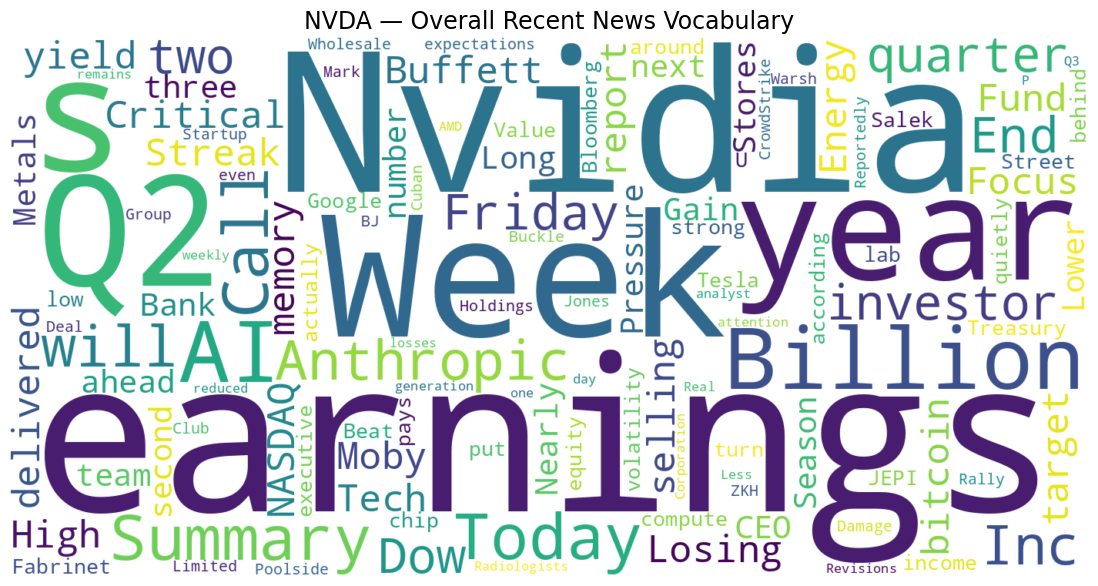

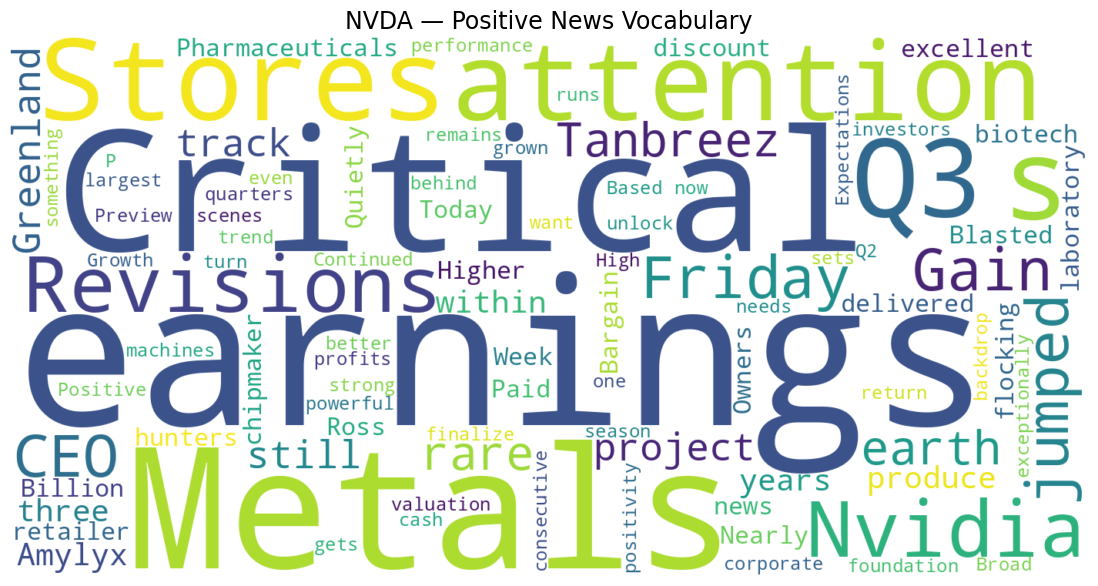

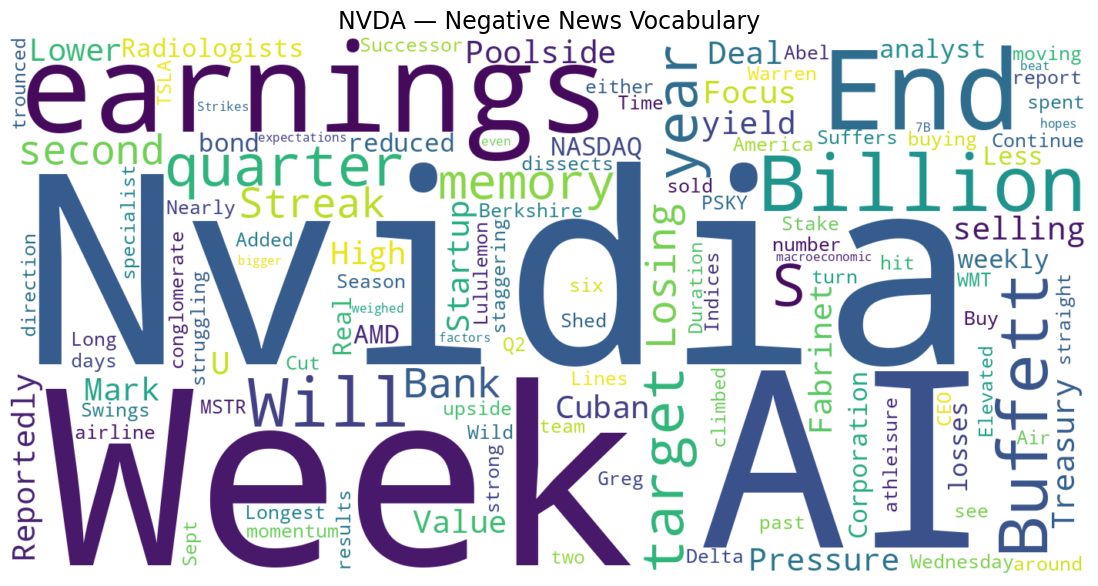

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.



In [19]:
#@title Word clouds + top 20 terms

!pip -q install wordcloud

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

custom_stopwords = set(STOPWORDS).union({
    TICKER.lower(),
    "stock",
    "stocks",
    "share",
    "shares",
    "company",
    "market",
    "markets",
    "said",
    "says",
    "new",
})


def make_wordcloud(text, title):
    text = str(text).strip()

    if not text:
        print(f"No text available for: {title}")
        return

    wc = WordCloud(
        width=1400,
        height=700,
        background_color="white",
        stopwords=custom_stopwords,
        max_words=120,
        collocations=False,
    ).generate(text)

    plt.figure(figsize=(16, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=17)
    plt.show()


all_text = " ".join(
    scored_news["text"]
    .dropna()
    .astype(str)
)

positive_text = " ".join(
    scored_news.loc[
        scored_news["sentiment_score"] >= SENTIMENT_BULLISH_THRESHOLD,
        "text",
    ]
    .dropna()
    .astype(str)
)

negative_text = " ".join(
    scored_news.loc[
        scored_news["sentiment_score"] <= SENTIMENT_BEARISH_THRESHOLD,
        "text",
    ]
    .dropna()
    .astype(str)
)

make_wordcloud(
    all_text,
    f"{TICKER} — Overall Recent News Vocabulary",
)

make_wordcloud(
    positive_text,
    f"{TICKER} — Positive News Vocabulary",
)

make_wordcloud(
    negative_text,
    f"{TICKER} — Negative News Vocabulary",
)


def top_terms(texts, n=20):
    texts = pd.Series(texts).dropna().astype(str)

    if texts.empty:
        return pd.DataFrame(columns=["term", "count"])

    vectorizer = CountVectorizer(
        stop_words=list(custom_stopwords),
        max_features=5000,
        ngram_range=(1, 2),
        min_df=1,
    )

    X = vectorizer.fit_transform(texts)

    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.asarray(vectorizer.get_feature_names_out())

    return (
        pd.DataFrame({
            "term": terms,
            "count": counts,
        })
        .sort_values("count", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )


positive_terms = top_terms(
    scored_news.loc[
        scored_news["sentiment_score"] >= SENTIMENT_BULLISH_THRESHOLD,
        "text",
    ],
    n=TOP_N,
)

negative_terms = top_terms(
    scored_news.loc[
        scored_news["sentiment_score"] <= SENTIMENT_BEARISH_THRESHOLD,
        "text",
    ],
    n=TOP_N,
)

fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.18,
    subplot_titles=(
        f"Top {TOP_N} positive-news terms",
        f"Top {TOP_N} negative-news terms",
    ),
)

if not positive_terms.empty:
    p = positive_terms.sort_values("count")
    fig.add_trace(
        go.Bar(
            x=p["count"],
            y=p["term"],
            orientation="h",
            marker_color=SENTIMENT_GREEN,
            name="Positive terms",
        ),
        row=1, col=1,
    )

if not negative_terms.empty:
    n = negative_terms.sort_values("count")
    fig.add_trace(
        go.Bar(
            x=n["count"],
            y=n["term"],
            orientation="h",
            marker_color=SENTIMENT_RED,
            name="Negative terms",
        ),
        row=1, col=2,
    )

fig.update_layout(
    title=f"{TICKER} — Ranked News Vocabulary",
    height=760,
    showlegend=False,
)

fig.show()